In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset and perform initial inspection

Load the dataset and review its basic structure:
- number of observations and features
- column names
- data types


In [2]:
df = pd.read_csv("data.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)

Shape: (111902, 24)

Columns:
 Index(['loan_id', 'loan_issue_date', 'loan_amount', 'amount_outstanding_14d',
       'amount_outstanding_21d', 'card_expiry_month', 'card_expiry_year',
       'existing_klarna_debt', 'num_active_loans', 'days_since_first_loan',
       'new_exposure_7d', 'new_exposure_14d', 'num_confirmed_payments_3m',
       'num_confirmed_payments_6m', 'num_failed_payments_3m',
       'num_failed_payments_6m', 'num_failed_payments_1y', 'amount_repaid_14d',
       'amount_repaid_1m', 'amount_repaid_3m', 'amount_repaid_6m',
       'amount_repaid_1y', 'merchant_group', 'merchant_category'],
      dtype='object')

Data types:
 loan_id                       object
loan_issue_date               object
loan_amount                    int64
amount_outstanding_14d         int64
amount_outstanding_21d         int64
card_expiry_month            float64
card_expiry_year             float64
existing_klarna_debt         float64
num_active_loans               int64
days_since_first_loan

### Check uniqueness of `loan_id`

Verify that `loan_id` is a unique identifier for each observation.
Duplicate IDs could indicate duplicated records or data ingestion issues

### Missing values analysis

Calculate the proportion of missing values for each feature in the dataset.
Features with high missing rates may require:
- imputation
- feature engineering
- or removal from the model.

In [3]:
print(df['loan_id'].is_unique)

missing_df = (
    df.isnull()
      .mean()
      .reset_index()
      .rename(columns={"index":"feature",0:"missing_rate"})
)

missing_df.sort_values("missing_rate", ascending=False)

True


,feature,missing_rate
7,existing_klarna_debt,0.261050
5,card_expiry_month,0.001385
6,card_expiry_year,0.001385
0,loan_id,0.000000
14,num_failed_payments_3m,0.000000
22,merchant_group,0.000000
21,amount_repaid_1y,0.000000
20,amount_repaid_6m,0.000000
19,amount_repaid_3m,0.000000
18,amount_repaid_1m,0.000000


In [4]:
# additional check
col = df['existing_klarna_debt']

result = {
    "positive": (col > 0).sum(),
    "zero": (col == 0).sum(),
    "negative": (col < 0).sum(),
    "missing": col.isna().sum()
}

print(result)

total = sum(result.values())
assert total == len(df)


{'positive': np.int64(42010), 'zero': np.int64(40621), 'negative': np.int64(59), 'missing': np.int64(29212)}


### Analysis of `existing_klarna_debt`

The variable **`existing_klarna_debt`** contains a significant number of missing values.  
Additionally, a small number of observations contain **negative values**, which require further investigation.

### Hypotheses

**Missing values may correspond to:**

- **New customers** who have no previous borrowing history with Klarna
- Customers whose **loan applications were underwritten but ultimately cancelled**, meaning the loan was never issued
- **Data recording issues or system errors**

**Negative values:**

- The proportion of negative values is **below 0.05% of the dataset**
- Such cases are likely due to **data inconsistencies or system bugs**
- Given their extremely low frequency, they can reasonably be **treated as data errors**





In [4]:
# check for New customer

pd.crosstab(
    df["days_since_first_loan"] == -1,
    df["existing_klarna_debt"].isna(),
    normalize="index"
)

existing_klarna_debt,False,True
days_since_first_loan,,
False,0.999762,0.000238
True,0.191638,0.808362


### Validation of Missing Values in `existing_klarna_debt`

To understand the nature of missing values in `existing_klarna_debt`, I compare them with the variable `days_since_first_loan`.

### Existing customers

For customers with a recorded loan history:

- **99.98%** have a value for `existing_klarna_debt`
- **0.02%** have missing values

Missing values therefore **almost never occur for existing customers**.  
The small proportion of **0.02%** is likely due to **data errors or data ingestion issues**.

### New customers (`days_since_first_loan == -1`)

For customers identified as new customers:

- **80.8%** have missing values for `existing_klarna_debt`
- **19.2%** have a recorded value

If these customers are truly **new**, they should not have any existing Klarna debt.  
The presence of non-missing values may indicate **data inconsistencies or limitations in how new customers are identified in the dataset**.

Missing values may contain predictive information, therefore a missing indicator should be created.







In [9]:
# Further analysis of non-missing values in existing_klarna_debt for customers classified as "new"

new_customers_with_existing_debt_0 = (df[(df["days_since_first_loan"] == -1) & (df["existing_klarna_debt"] == 0)].shape[0])

print(df[(df["days_since_first_loan"] == -1) & (df["existing_klarna_debt"] > 0)][["loan_amount", "days_since_first_loan", "existing_klarna_debt"]])


print(df[(df["days_since_first_loan"] == -1) & (df["existing_klarna_debt"] == 0)]["loan_amount"].shape)


        loan_amount  days_since_first_loan  existing_klarna_debt
407            7044                     -1               14088.0
1178          46265                     -1                2124.0
1767           9256                     -1               18512.0
1823           5506                     -1               11012.0
4000           3700                     -1                7400.0
...             ...                    ...                   ...
105029         5511                     -1                8262.0
106346         6285                     -1               17622.0
108076        22050                     -1               44100.0
110897        17877                     -1               23402.0
111749         2320                     -1                3200.0

[106 rows x 3 columns]
(6815,)


In [13]:
mask = (df["existing_klarna_debt"] == 2 * df["loan_amount"]) & (df["days_since_first_loan"] == -1)

strange_rows = df[mask]

print("Number of rows:", len(strange_rows))

Number of rows: 34


#### Further Investigation of Non-Missing Values for New Customers

Among customers classified as new (`days_since_first_loan == -1`), **19.2%** have non-missing values for `existing_klarna_debt`.

- **6,815** cases where `existing_klarna_debt = 0`
- **106** cases where `existing_klarna_debt > 0`

Further analysis of the 106 positive values revealed a suspicious pattern:

- **34 observations** follow the rule  
  `existing_klarna_debt = 2 × loan_amount`

This pattern suggests the presence of **data inconsistencies or system-generated values**, rather than genuine historical debt.

### Interpretation

- Most non-missing values correspond to **zero debt**, which is consistent with customers having no prior borrowing history.
- The small number of positive values likely reflects **data artefacts or system issues** rather than real existing debt.

These findings further support the hypothesis that **missing values in `existing_klarna_debt` primarily indicate new customers with no previous Klarna debt**.

### Data imbalance investigation :

In [15]:
df["default_21"] = (df["amount_outstanding_21d"] > 0).astype(int)

print(df['default_21'].value_counts())

print(df['default_21'].value_counts(normalize=True))

default_21
0    105813
1      6089
Name: count, dtype: int64
default_21
0    0.945586
1    0.054414
Name: proportion, dtype: float64


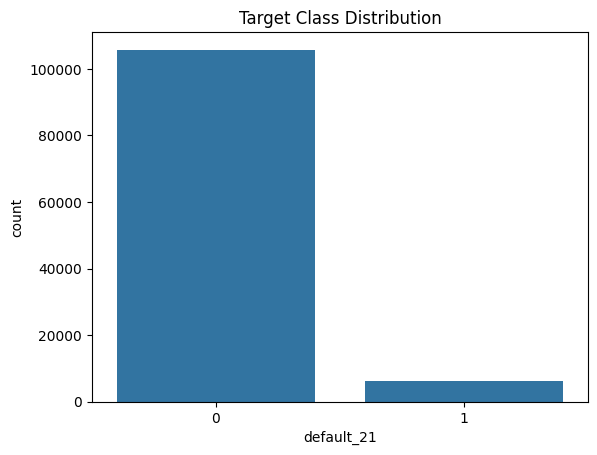

In [16]:
sns.countplot(x='default_21', data=df)
plt.title("Target Class Distribution")
plt.show()

The dataset shows a strong class imbalance, which is typical for credit scoring problems where default events are relatively rare. 

Methods for addressing class imbalance should therefore be considered during model training.

### Outliers detection (are very common credit scoring datasets)

In [17]:
continuous_vars = df.select_dtypes(include=["number"]).columns.tolist()

continuous_vars

['loan_amount',
 'amount_outstanding_14d',
 'amount_outstanding_21d',
 'card_expiry_month',
 'card_expiry_year',
 'existing_klarna_debt',
 'num_active_loans',
 'days_since_first_loan',
 'new_exposure_7d',
 'new_exposure_14d',
 'num_confirmed_payments_3m',
 'num_confirmed_payments_6m',
 'num_failed_payments_3m',
 'num_failed_payments_6m',
 'num_failed_payments_1y',
 'amount_repaid_14d',
 'amount_repaid_1m',
 'amount_repaid_3m',
 'amount_repaid_6m',
 'amount_repaid_1y',
 'default_21']

In [25]:
continuous_vars = ['loan_amount',
 'amount_outstanding_14d',
 'amount_outstanding_21d',
 'num_active_loans',
 'new_exposure_7d',
 'new_exposure_14d',
 'num_confirmed_payments_3m',
 'num_confirmed_payments_6m',
 'num_failed_payments_3m',
 'num_failed_payments_6m',
 'num_failed_payments_1y',
 'amount_repaid_14d',
 'amount_repaid_1m',
 'amount_repaid_3m',
 'amount_repaid_6m']

def detect_outliers_zscore(df, column, threshold=3):
    z = np.abs(stats.zscore(df[column]))
    return df[z > threshold]

In [26]:
outliers = {var: detect_outliers_zscore(df, var) for var in continuous_vars}

outlier_counts = {key: len(value) for key, value in outliers.items()}

for var, count in outlier_counts.items():
    print(f"{var}: {count} rows")

loan_amount: 2176 rows
amount_outstanding_14d: 1623 rows
amount_outstanding_21d: 1275 rows
num_active_loans: 2341 rows
new_exposure_7d: 1938 rows
new_exposure_14d: 2063 rows
num_confirmed_payments_3m: 2070 rows
num_confirmed_payments_6m: 2013 rows
num_failed_payments_3m: 1344 rows
num_failed_payments_6m: 1238 rows
num_failed_payments_1y: 1383 rows
amount_repaid_14d: 2154 rows
amount_repaid_1m: 2117 rows
amount_repaid_3m: 2140 rows
amount_repaid_6m: 1973 rows


In [27]:
# extreme outliers values

outliers = {var: detect_outliers_zscore(df, var,threshold=4) for var in continuous_vars}

outlier_counts = {key: len(value) for key, value in outliers.items()}

for var, count in outlier_counts.items():
    print(f"{var}: {count} rows")

loan_amount: 1241 rows
amount_outstanding_14d: 1017 rows
amount_outstanding_21d: 809 rows
num_active_loans: 973 rows
new_exposure_7d: 1195 rows
new_exposure_14d: 1253 rows
num_confirmed_payments_3m: 1114 rows
num_confirmed_payments_6m: 1106 rows
num_failed_payments_3m: 1344 rows
num_failed_payments_6m: 1062 rows
num_failed_payments_1y: 719 rows
amount_repaid_14d: 1249 rows
amount_repaid_1m: 1184 rows
amount_repaid_3m: 1170 rows
amount_repaid_6m: 1098 rows


All continuous variables display evidence of outliers in their distributions.

### Skewness presence (right-skewness is typical for credit scoring datasets)

In [36]:
df.skew(numeric_only=True)

loan_amount                   5.208107
amount_outstanding_14d       14.297038
amount_outstanding_21d       20.220318
card_expiry_month             0.056772
card_expiry_year              0.234178
existing_klarna_debt          5.138871
num_active_loans              6.359207
days_since_first_loan         0.911492
new_exposure_7d               9.526733
new_exposure_14d              7.976452
num_confirmed_payments_3m     6.783512
num_confirmed_payments_6m     7.031119
num_failed_payments_3m       16.140279
num_failed_payments_6m       17.143191
num_failed_payments_1y       61.504064
amount_repaid_14d             6.538471
amount_repaid_1m              6.817919
amount_repaid_3m              6.556677
amount_repaid_6m              9.666965
amount_repaid_1y             10.832431
default_21                    3.928828
dtype: float64

Most of the variables have high positive skew

### Data Leakage

An important step in model development is checking for potential data leakage.  

Data leakage occurs when variables contain information that would not be available at the time of the credit decision but are still used during model training.

Such variables may show a strong correlation with the target variable, which can lead to overly optimistic model performance during development.

Therefore, only variables that are available at the moment of the loan decision should be included in the model.

This potential data leakage will be investigated during model developmrnt.